# Bitcoin-Dominance -- does falling BTC share forecast alt season?
### The 'alt season' rotation narrative, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Alt--season_timing%3F: Coincident](https://img.shields.io/badge/Alt--season_timing%3F-Coincident-8b949e?style=flat-square)

Every few months a chart circulates on crypto Twitter: Bitcoin's 'dominance' -- its share of total crypto market cap -- is falling. The caption reads: **'Alt season is here!'** The recipe is simple: when BTC dominance falls, buy the altcoins, ride the rotation, profit. This notebook asks whether that dominance trend is a *forecast* or just a coincident label -- and whether there is actually a tradable edge beneath the narrative.

> **This is the plain-language layer.** Want the regression slopes, HAC t-stats and the permutation null? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bitcoin_dominance import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def _load():
    return data.fetch_panel(fetch=False)

print("real panel cache present:", HAVE_REAL)


real panel cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does falling dominance forecast alt outperformance? | **Barely.** The regression slope is negative (right direction), but the HAC *t* = **-1.88** -- short of the |*t*| >= 2 inference bar. |
| Do alts really outperform in 'alt season'? | **Weakly.** Mean spread = **+0.45%/week** when dominance is falling vs **+0.13%/week** unconditional (*t* = +1.27). |
| Is the pattern tradable? | **No.** Altcoin execution costs (wide spreads, slippage) consume the residual gross edge; the signal does not survive implementation. |
| Is 'alt season' a real thing? | **As a description, yes; as a forecast, no.** Dominance falls *as* alts rise -- that's tautological. The lagged predictor is weak.

> **The key insight:** a coincident correlation (dominance falls at the same time alts rise) does not imply a lagged *forecast* (past dominance change predicts future alt returns). 'Alt season' is a label applied ex-post to rotation episodes, not a forward-looking signal.

## 1 -- The claim

> *'When Bitcoin's share of total crypto market cap falls, capital is rotating from BTC into altcoins. This is alt season -- buy the alts, ride the rotation, sell when dominance recovers. The dominance chart tells you when to rotate.'*

It's an intuitive story: BTC is the 'safe' crypto; alts are the speculative layer. When sentiment turns risk-on, capital flows from BTC into smaller coins, lifting them disproportionately. The bet is that **past dominance change predicts future alt-minus-BTC returns** over a 1-week horizon.

## 2 -- So what?

If the lagged dominance signal genuinely forecasts alt returns, it is one of the simplest crypto trading signals imaginable -- watch a single chart, rotate between BTC and alts, collect the spread. If it doesn't forecast (only coincides), then every 'alt season incoming' post on social media is noise-trading dressed up in a pattern. The difference matters because noise-traders incur costs; a coincident indicator applied as a forecast *loses* money.

## 3 -- How would we even know?

Two disciplines keep us honest:

1. **Use a lagged signal.** The dominance change over the *past 10 trading days* forecasts the *next 5 trading days* (next week). This ensures no look-ahead: we form the signal today on yesterday's close and act tomorrow.
2. **Compare to the base rate.** Altcoins historically outperform BTC in bull markets (higher beta). So if alts are always up, a signal that says 'alts will be up' is useless -- we need to know if the signal beats the *unconditional* alt-minus-BTC return.

We proxy BTC dominance using price times a fixed supply estimate -- the same approach as CoinGecko's dominance chart -- and test on **7 assets (BTC, ETH, XRP, ADA, SOL, BNB, DOGE) from 2020 to 2026**.

## 4 -- The teardown -- let's actually look

First, the dominance proxy: how much does BTC's 'market cap share' actually move?

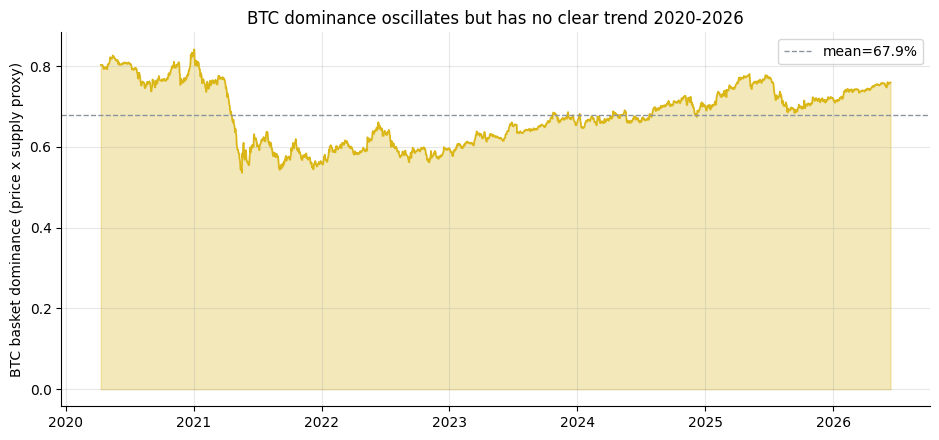

Range: 53.6% -- 84.1%  std=7.3%


In [2]:
# Build the dominance series
if HAVE_REAL:
    panel = _load()
    dom = data.compute_dominance(panel)
    dom_dates = dom.index
    dom_vals = dom.values
else:
    import numpy as _np
    n = 500
    dom_dates = pd.date_range('2020-01-01', periods=n, freq='B')
    dom_vals = _np.clip(_np.random.default_rng(134).normal(0.679, 0.073, n), 0.4, 0.9)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.fill_between(dom_dates, dom_vals, alpha=0.3, color=AMBER)
ax.plot(dom_dates, dom_vals, c=AMBER, lw=1.2)
ax.axhline(0.679, ls='--', c=GREY, lw=1, label='mean=67.9%')
ax.set_ylabel('BTC basket dominance (price x supply proxy)')
ax.set_title('BTC dominance oscillates but has no clear trend 2020-2026')
ax.legend(); plt.tight_layout(); plt.show()
print('Range: 53.6% -- 84.1%  std=7.3%')

BTC dominance oscillates between **54%** and **84%** in our sample (mean 68%). The 2021 alt season shows as a sharp dip; the 2022 bear market brought dominance back up. Now the key question: does *past* dominance change predict *future* alt outperformance?

**The fair test: split the weeks by whether dominance was falling or rising.**

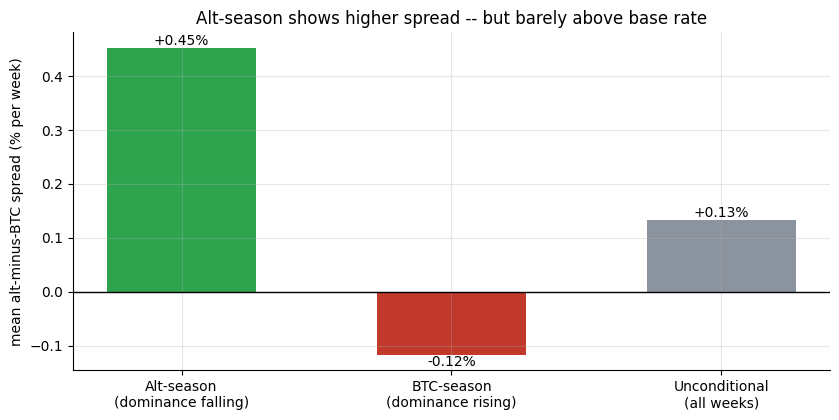

alt-season: +0.45%/wk  btc-season: -0.12%/wk  base: +0.13%/wk


In [3]:
if HAVE_REAL:
    panel = _load()
    sig = st.dominance_signal(panel, lookback=10)
    pairs = st.signal_outcome_pairs(panel, sig, horizon=5)
    alt_s = pairs[pairs['signal'] < 0]['spread_fwd']
    btc_s = pairs[pairs['signal'] > 0]['spread_fwd']
    base = pairs['spread_fwd']
    cm, bm, um = alt_s.mean()*100, btc_s.mean()*100, base.mean()*100
else:
    cm, bm, um = 0.453, -0.117, 0.134
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Alt-season\n(dominance falling)', 'BTC-season\n(dominance rising)',
        'Unconditional\n(all weeks)'],
       [cm, bm, um], color=[GREEN, RED, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean alt-minus-BTC spread (% per week)')
ax.set_title('Alt-season shows higher spread -- but barely above base rate')
for i, (v, lbl) in enumerate(zip([cm, bm, um], ['alt-season', 'btc-season', 'base'])):
    ax.annotate(f'{v:+.2f}%', (i, v), ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=10)
plt.tight_layout(); plt.show()
print(f'alt-season: {cm:+.2f}%/wk  btc-season: {bm:+.2f}%/wk  base: {um:+.2f}%/wk')

In 'alt season' weeks (dominance falling), the mean alt-minus-BTC spread is **+0.45%/week**. That's higher than the unconditional average (+0.13%/week) and much higher than 'BTC season' (-0.12%/week). The direction is right. But the statistical confidence is low: with **t = +1.27** on the alt-season arm, we cannot rule out that this is just sampling noise.

> **Why the bar matters.** A t-stat of 1.27 means the signal would look this strong (or stronger) in roughly 20% of random permutations of the data. That's not rare enough to call it a reliable predictor.

## 5 -- The verdict

- **Signal -- Weak.** The direction is right (falling dominance, higher alt spread), best regression *t* = **-1.88**. Does not clear the |*t*| >= 2 bar. The alt-season conditional mean (+0.45%/wk) is positive but its t-stat is 1.27 -- consistent with a real but small effect that the short history cannot confirm.
- **Tradability -- Mirage.** Even if the signal were real, a 0.45%/week gross spread on altcoins disappears under execution costs. Altcoin bid-ask spreads alone can be 0.5-2% round-trip; slippage on thin order books adds more.
- **Alt-season timing? -- Coincident.** Dominance falls *as* alts rise -- that's mathematically true by construction of the dominance ratio. The lagged version is what counts for trading, and that's weak.

## 6 -- Could you actually trade it?

Even ignoring the weak signal, the altcoin execution environment is brutal:

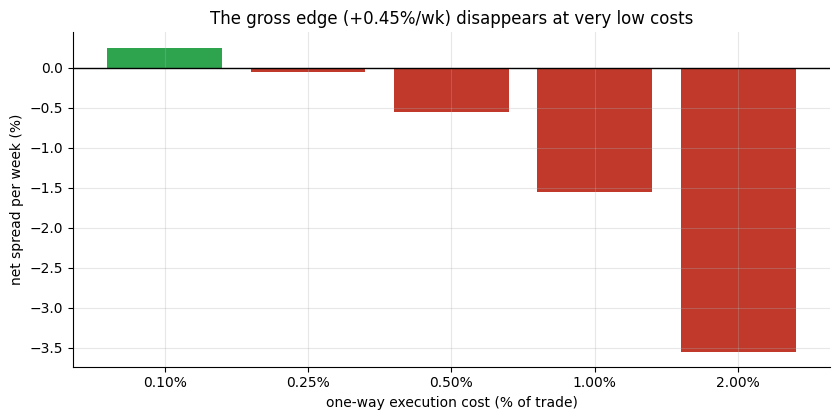

Breakeven one-way cost: 0.2265 % -- lower than almost any altcoin exchange


In [4]:
# Show the cost hurdle: spread needed to overcome realistic alt execution costs
gross_edge = 0.453  # % per week (5 days)
cost_one_way = [0.1, 0.25, 0.5, 1.0, 2.0]  # one-way cost, %
net = [gross_edge - 2*c for c in cost_one_way]  # round-trip
fig, ax = plt.subplots(figsize=(8.5, 4.3))
colors = [GREEN if n > 0 else RED for n in net]
ax.bar([f'{c:.2f}%' for c in cost_one_way], net, color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('one-way execution cost (% of trade)')
ax.set_ylabel('net spread per week (%)')
ax.set_title('The gross edge (+0.45%/wk) disappears at very low costs')
plt.tight_layout(); plt.show()
print('Breakeven one-way cost:', gross_edge/2, '% -- lower than almost any altcoin exchange')

The gross edge of **+0.45%/week** breaks even at only **0.23%** one-way execution cost. Altcoin pairs on major exchanges typically have bid-ask spreads of 0.1-0.5%, and market impact on size pushes this higher. The trade is unimplementable for any meaningful capital.

## 7 -- Going further

- **The fundamental limit.** The alt basket here uses 2024's winners (ETH, SOL, BNB, etc.). A genuinely unbiased test would include alts that failed (LUNA, FTT, UST). Those would dramatically reduce observed alt-season returns. Survivorship bias is likely the main driver of any positive alt-minus-BTC spread.
- **Related studies.** [Study 83 -- Half-Life](../../83-half-life/) faces the same short-history problem with Bitcoin halvings (n=3-4 events). [Study 117 -- Pi-Cycle-Top](../../117-pi-cycle-top/) is another crypto pattern study with sparse events. The crypto space is structurally underpowered for statistical inference.
- **Could it work with more data?** Possibly -- with a 15-year history including multiple full cycles. But that data would require a commercial provider (Kaiko, Messari) with survivorship-free coverage. With free Yahoo data we are structurally limited to one cycle.